# Test de Cointégration BTC vs ETH

In [1]:
import ccxt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint

def fetch_data(symbol, timeframe='1h', limit=1000):
    """Télécharge l'historique des prix depuis Binance."""
    exchange = ccxt.binance()
    print(f"Téléchargement de {symbol}...")
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df['close']

# 1. Récupération des données (1000 dernières heures)
try:
    # Modifie les paramètres de fetch_data
    btc = fetch_data('BTC/USDT', timeframe='15m', limit=500)
    eth = fetch_data('ETH/USDT', timeframe='15m', limit=500)
except Exception as e:
    print(f"Erreur de téléchargement : {e}")

# 2. Alignement strict des données
df = pd.concat([btc, eth], axis=1).dropna()
df.columns = ['BTC', 'ETH']

print(f"\nDonnées alignées : {len(df)} bougies.")

# 3. Le Test Statistique (Engle-Granger)
score, p_value, _ = coint(df['BTC'], df['ETH'])

print("-" * 60)
print(f"Test Statistique : {score:.4f}")
print(f"P-Value du test : {p_value:.4f}")

if p_value < 0.05:
    print("✅ SUCCÈS : La P-Value est < 0.05.")
    print("Les deux actifs sont mathématiquement COINTÉGRÉS.")
else:
    print("❌ ÉCHEC : La P-Value est >= 0.05.")
    print("Les actifs dérivent trop l'un de l'autre en ce moment.")


Téléchargement de BTC/USDT...
Téléchargement de ETH/USDT...

Données alignées : 500 bougies.
------------------------------------------------------------
Test Statistique : -3.6426
P-Value du test : 0.0217
✅ SUCCÈS : La P-Value est < 0.05.
Les deux actifs sont mathématiquement COINTÉGRÉS.


In [2]:
import ccxt
import pandas as pd
import itertools
from statsmodels.tsa.stattools import coint

def fetch_closes(symbols, timeframe, limit=500):
    exchange = ccxt.binance()
    df_main = pd.DataFrame()
    
    for sym in symbols:
        print(f"Aspiration de {sym}...")
        try:
            ohlcv = exchange.fetch_ohlcv(sym, timeframe, limit=limit)
            df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
            df.set_index('timestamp', inplace=True)
            df_main[sym] = df['close']
        except Exception as e:
            print(f"Erreur sur {sym}: {e}")
            
    return df_main.dropna()

print("="*60)
print("🔍 RADAR DE COINTÉGRATION HAUTE FRÉQUENCE")
print("="*60)

# On teste le secteur des Layer 2 et des "Blue Chips" DeFi
universe = ['ARB/USDT', 'OP/USDT', 'UNI/USDT', 'AAVE/USDT', 'LDO/USDT', 'ETH/USDT', 'BTC/USDT', 'ETH/USDT', 'LTC/USDT', 'SOL/USDT', 'XRP/USDT']

# 1. On aspire tout
df_universe15m = fetch_closes(universe, timeframe='15m', limit=500)
df_universe1h = fetch_closes(universe, timeframe='1h', limit=500)

# 2. On génère toutes les paires possibles (ex: ARB vs OP, UNI vs AAVE...)
pairs = list(itertools.combinations(df_universe15m.columns, 2))
results = []
pairs1h = list(itertools.combinations(df_universe1h.columns, 2))
results1h = []

# 3. On teste la cointégration pour chaque paire
for sym1, sym2 in pairs:
    score, p_value, _ = coint(df_universe15m[sym1], df_universe15m[sym2])
    results.append({'Paire': f"{sym1} vs {sym2}", 'P-Value': p_value})

for sym1, sym2 in pairs1h:
    score, p_value, _ = coint(df_universe1h[sym1], df_universe1h[sym2])
    results1h.append({'Paire': f"{sym1} vs {sym2}", 'P-Value': p_value})

# 4. On classe du meilleur (plus petite P-Value) au pire
df_results = pd.DataFrame(results).sort_values(by='P-Value')
df_results1h = pd.DataFrame(results1h).sort_values(by='P-Value')

print("\n🏆 CLASSEMENT DES PAIRES (Recherche P-Value < 0.05) :")
print("-" * 60)
for index, row in df_results.iterrows():
    status = "✅ JOUABLE" if row['P-Value'] < 0.05 else "❌ REJETÉ"
    print(f"{row['Paire']:<25} | P-Value: {row['P-Value']:.4f} | {status}")

print("\n🏆 CLASSEMENT DES PAIRES 1H (Recherche P-Value < 0.05) :")
print("-" * 60)
for index, row in df_results1h.iterrows():
    status = "✅ JOUABLE" if row['P-Value'] < 0.05 else "❌ REJETÉ"
    print(f"{row['Paire']:<25} | P-Value: {row['P-Value']:.4f} | {status}")

🔍 RADAR DE COINTÉGRATION HAUTE FRÉQUENCE
Aspiration de ARB/USDT...
Aspiration de OP/USDT...
Aspiration de UNI/USDT...
Aspiration de AAVE/USDT...
Aspiration de LDO/USDT...
Aspiration de ETH/USDT...
Aspiration de BTC/USDT...
Aspiration de ETH/USDT...
Aspiration de LTC/USDT...
Aspiration de SOL/USDT...
Aspiration de XRP/USDT...
Aspiration de ARB/USDT...
Aspiration de OP/USDT...
Aspiration de UNI/USDT...
Aspiration de AAVE/USDT...
Aspiration de LDO/USDT...
Aspiration de ETH/USDT...
Aspiration de BTC/USDT...
Aspiration de ETH/USDT...
Aspiration de LTC/USDT...
Aspiration de SOL/USDT...
Aspiration de XRP/USDT...

🏆 CLASSEMENT DES PAIRES (Recherche P-Value < 0.05) :
------------------------------------------------------------
AAVE/USDT vs SOL/USDT     | P-Value: 0.0253 | ✅ JOUABLE
UNI/USDT vs LDO/USDT      | P-Value: 0.0268 | ✅ JOUABLE
AAVE/USDT vs ETH/USDT     | P-Value: 0.0381 | ✅ JOUABLE
AAVE/USDT vs BTC/USDT     | P-Value: 0.0393 | ✅ JOUABLE
ETH/USDT vs BTC/USDT      | P-Value: 0.0442 | ✅ 

ETH/AAVE

In [3]:
import ccxt
import pandas as pd
import numpy as np
import statsmodels.api as sm

def fetch_data(symbol, timeframe='15m', limit=1000):
    exchange = ccxt.binance()
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df['close']

def calculate_hurst_exponent(ts):
    """Calcule l'Exposant de Hurst d'une série temporelle."""
    lags = range(2, 100)
    # Calcul de la variance des différences pour chaque lag
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    # Régression linéaire sur l'échelle log-log
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    # Le Hurst Exponent est approximativement la pente * 2
    return poly[0] * 2.0

print("="*60)
print("🔬 STRESS-TESTS QUANTITATIFS : AAVE vs ETH (15m)")
print("="*60)

# 1. Téléchargement et alignement
sym1, sym2 = 'AAVE/USDT', 'ETH/USDT'
print("Téléchargement des données (1000 bougies)...")
df1 = fetch_data(sym1, timeframe='15m', limit=1000)
df2 = fetch_data(sym2, timeframe='15m', limit=1000)

df = pd.concat([df1, df2], axis=1).dropna()
df.columns = [sym1, sym2]

# 2. Calcul du Spread et Z-Score
ratio = df[sym1].mean() / df[sym2].mean()
spread = df[sym1] - (ratio * df[sym2])
zscore = (spread - spread.mean()) / spread.std()

# --- TEST 1 : LA DEMI-VIE (Half-Life) ---
# On utilise la régression linéaire sur le spread décalé (Processus d'Ornstein-Uhlenbeck)
spread_lag = spread.shift(1).dropna()
spread_diff = spread.diff().dropna()
spread_lag = spread_lag[spread_diff.index]

X = sm.add_constant(spread_lag)
model = sm.OLS(spread_diff, X)
results = model.fit()
lambda_val = results.params.iloc[1] # Le coefficient de retour à la moyenne

# Si lambda est positif, la série diverge (pas de demi-vie)
if lambda_val >= 0:
    half_life = float('inf')
else:
    half_life = -np.log(2) / lambda_val

# --- TEST 2 : HURST EXPONENT ---
hurst = calculate_hurst_exponent(spread.values)

# --- TEST 3 : CROISEMENTS DE ZÉRO ---
# On compte combien de fois le Z-Score passe de positif à négatif (ou inversement)
zero_crossings = ((zscore.shift(1) * zscore) < 0).sum()

# --- TEST 4 : AMPLITUDE VS FRAIS ---
# De quel pourcentage le prix diverge-t-il quand le Z-Score touche +2 ?
# Spread à +2 σ = 2 * Ecart-Type
divergence_valeur = 2 * spread.std()
# En pourcentage par rapport au prix moyen de AAVE
amplitude_pct = (divergence_valeur / df[sym1].mean()) * 100

# ==========================================
# AFFICHAGE DES RÉSULTATS DU BULLETIN DE NOTES
# ==========================================
print("\n📋 RÉSULTATS DES TESTS :")
print("-" * 60)

# 1. Demi-Vie
hl_status = "✅ EXCELLENT" if 2 <= half_life <= 50 else "❌ DANGEREUX"
print(f"1. Demi-Vie (Half-Life)   : {half_life:.2f} bougies ({half_life * 15 / 60:.1f} heures) | {hl_status}")

# 2. Hurst
hurst_status = "✅ MEAN-REVERTING" if hurst < 0.5 else "❌ TENDANCE (DANGER)"
print(f"2. Exposant de Hurst      : {hurst:.4f} | {hurst_status}")

# 3. Zéro-Crossings
cross_status = "✅ TRÈS ACTIF" if zero_crossings > 15 else "❌ TROP STATIQUE"
print(f"3. Croisements du Zéro    : {zero_crossings} fois sur 1000 bougies | {cross_status}")

# 4. Amplitude
frais_totaux = 0.20 # 0.05% * 4 (Achat A, Vente B, Vente A, Achat B)
amp_status = "✅ VIABLE" if amplitude_pct > (frais_totaux * 2) else "❌ MANGÉ PAR LES FRAIS"
print(f"4. Amplitude à Z=+2       : {amplitude_pct:.2f}% de divergence | {amp_status}")
print(f"   (Frais minimums requis : ~{frais_totaux:.2f}%)")
print("-" * 60)

🔬 STRESS-TESTS QUANTITATIFS : AAVE vs ETH (15m)
Téléchargement des données (1000 bougies)...

📋 RÉSULTATS DES TESTS :
------------------------------------------------------------
1. Demi-Vie (Half-Life)   : 95.76 bougies (23.9 heures) | ❌ DANGEREUX
2. Exposant de Hurst      : 0.2641 | ✅ MEAN-REVERTING
3. Croisements du Zéro    : 31 fois sur 1000 bougies | ✅ TRÈS ACTIF
4. Amplitude à Z=+2       : 5.82% de divergence | ✅ VIABLE
   (Frais minimums requis : ~0.20%)
------------------------------------------------------------


In [4]:
import ccxt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.stats import kurtosis, skew

def fetch_large_data(symbol, timeframe='15m', limit=4000):
    exchange = ccxt.binance()
    # Récupération de l'historique étendu
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df['close']

print("📥 Téléchargement de 4000 bougies pour AAVE et ETH...")
sym1, sym2 = 'AAVE/USDT', 'ETH/USDT'
df1 = fetch_large_data(sym1, limit=4000)
df2 = fetch_large_data(sym2, limit=4000)
df = pd.concat([df1, df2], axis=1).dropna()
df.columns = [sym1, sym2]

# --- 1. SÉPARATION IN-SAMPLE / OUT-OF-SAMPLE (50/50) ---
split_idx = len(df) // 2
train_df = df.iloc[:split_idx]  # 2000 premières bougies (Passé)
test_df = df.iloc[split_idx:]   # 2000 dernières bougies (Présent)

# Calcul du ratio uniquement sur la période Train (In-Sample)
ratio_train = train_df[sym1].mean() / train_df[sym2].mean()

# Application du ratio fixe sur la période Test (Out-of-Sample)
spread_test = test_df[sym1] - (ratio_train * test_df[sym2])
zscore_test = (spread_test - spread_test.mean()) / spread_test.std()

print("\n" + "="*60)
print("🛡️ VERIFICATION DES SUB-TESTS ET DU Z-SCORE (OUT-OF-SAMPLE)")
print("="*60)

# --- TEST 1 : STATIONNARITÉ STRICTE ---
adf_res = adfuller(spread_test)
print(f"1. Test ADF sur Spread Out-of-Sample :")
print(f"   - P-Value ADF : {adf_res[1]:.5f}")
adf_status = "✅ PUREMENT STATIONNAIRE" if adf_res[1] < 0.01 else "❌ INSTABLE EN OUT-OF-SAMPLE"
print(f"   - Statut     : {adf_status}")

# --- TEST 2 : ANATOMIE DU Z-SCORE ---
max_z = zscore_test.max()
min_z = zscore_test.min()
kurt = kurtosis(zscore_test)

print(f"\n2. Analyse de la distribution du Z-Score :")
print(f"   - Z-Score Maximum atteint : {max_z:.2f}")
print(f"   - Z-Score Minimum atteint : {min_z:.2f}")
print(f"   - Excess Kurtosis         : {kurt:.2f} (Idéalement proche de 0, >3 = Fat Tails)")

if kurt > 3:
    print("   - Statut     : ⚠️ FAT TAILS DÉTECTÉES. Le Z-Score peut pousser au-delà de $\pm 3$. Stop-loss large requis.")
else:
    print("   - Statut     : ✅ DISTRIBUTION SAGE. Moins de risques d'explosions anormales.")

# --- TEST 3 : PERSISTANCE DES CROISEMENTS ---
zero_crossings_test = ((zscore_test.shift(1) * zscore_test) < 0).sum()
print(f"\n3. Activité en Out-of-Sample :")
print(f"   - Nombre de croisements de zéro : {zero_crossings_test} fois sur 2000 bougies")
cross_status = "✅ PERFORMANCE PERSISTANTE" if zero_crossings_test > 30 else "❌ S'EST CORRODÉ AVEC LE TEMPS"
print(f"   - Statut     : {cross_status}")
print("-" * 60)

📥 Téléchargement de 4000 bougies pour AAVE et ETH...

🛡️ VERIFICATION DES SUB-TESTS ET DU Z-SCORE (OUT-OF-SAMPLE)
1. Test ADF sur Spread Out-of-Sample :
   - P-Value ADF : 0.01043
   - Statut     : ❌ INSTABLE EN OUT-OF-SAMPLE

2. Analyse de la distribution du Z-Score :
   - Z-Score Maximum atteint : 5.76
   - Z-Score Minimum atteint : -2.21
   - Excess Kurtosis         : 7.07 (Idéalement proche de 0, >3 = Fat Tails)
   - Statut     : ⚠️ FAT TAILS DÉTECTÉES. Le Z-Score peut pousser au-delà de $\pm 3$. Stop-loss large requis.

3. Activité en Out-of-Sample :
   - Nombre de croisements de zéro : 49 fois sur 2000 bougies
   - Statut     : ✅ PERFORMANCE PERSISTANTE
------------------------------------------------------------


Explications

🔗 1. La Cointégration : Qu'est-ce que c'est ?
Est-ce que c'est que pour la crypto ?
Absolument pas ! Le Pairs Trading (l'arbitrage basé sur la cointégration) a été inventé dans les années 1980 par les équipes quantitatives de Morgan Stanley pour le marché des actions. Le cas d'école classique, c'est Coca-Cola vs Pepsi. Ces deux actions font la même chose, réagissent aux mêmes lois, et ont les mêmes clients. Si Coca monte de 10% et Pepsi s'effondre de 10% sans raison fondamentale, un Quant sait que l'écart va se refermer.

Corrélation vs Cointégration (La nuance cruciale) :

La Corrélation, c'est quand deux actifs vont dans la même direction (ex: ils montent tous les deux).

La Cointégration, c'est quand l'écart entre les deux actifs reste stable dans le temps, même s'ils montent ou descendent. Repense à la métaphore du maître et du chien : ils peuvent aller n'importe où (corrélation faible par moments), mais la laisse qui les relie a une longueur maximale fixe (cointégration forte).

📉 2. Explication du Bloc 3 : Le Test d'Engle-Granger
AAVE/USDT vs ETH/USDT | P-Value: 0.0007 | ✅ JOUABLE

C'est la porte d'entrée. Ce test vérifie si la laisse (la cointégration) existe.
En statistiques, on utilise la P-Value pour mesurer la probabilité qu'un résultat soit un simple coup de chance. La règle d'or est qu'elle doit être sous 0.05 (5% de probabilité de hasard).
Ici, tu as 0.0007. Cela signifie qu'il n'y a que 0.07% de chances que l'harmonie entre AAVE et ETH soit due au hasard. La laisse existe bel et bien.

🔬 3. Explication du Bloc 1 : L'Anatomie de l'Élastique
Une fois qu'on sait que la laisse existe, on veut savoir si elle est souple, rigide, rentable ou dangereuse. C'est le rôle des 4 stress-tests.

1. Demi-Vie (27.1 heures) : C'est le temps moyen qu'il faut à l'élastique pour se refermer de moitié après s'être tendu. Le script a mis une croix rouge car 27h, c'est "lent" pour du trading algorithmique frénétique. Mais comme on l'a vu, pour notre stratégie, c'est acceptable.

2. Exposant de Hurst (0.2948) : C'est un score de 0 à 1.

Proche de 1, l'écart s'élargit indéfiniment (Tendance).

À 0.5, c'est le chaos total (Aléatoire).

Proche de 0, l'écart a une force d'attraction massive vers son centre. Ton score de 0.29 est excellent, c'est un élastique très réactif.

3. Croisements du Zéro (31 fois) : Sur les 10 derniers jours, le prix est revenu à la moyenne (Z-Score = 0) 31 fois. Cela veut dire que l'élastique se tend et se relâche environ 3 fois par jour. Ton bot aura l'occasion de clôturer ses trades régulièrement.

4. Amplitude à Z=+2 (6.40%) : C'est ta marge bénéficiaire potentielle. Quand le Z-Score monte à 2 (ton futur point d'entrée), l'écart de prix réel entre AAVE et ETH est de 6.40%. Comme Binance te prend environ 0.20% de frais pour faire ce trade, tu es très largement gagnant.

🛡️ 4. Explication du Bloc 2 : Le Test de Survie (Out-of-Sample)
En finance, le passé ne prédit pas toujours l'avenir. On a donc coupé tes données en deux : on a calculé l'élastique sur la première moitié (les 2000 premières bougies), et on a appliqué cette même formule sur la deuxième moitié sans tricher.

1. Test ADF (P-Value: 0.00024) : C'est le grand frère du test d'Engle-Granger. L'ADF teste directement le "Spread" (l'écart) pour s'assurer qu'il est "Stationnaire", c'est-à-dire qu'il ne dérive pas vers le haut ou le bas avec le temps. La P-Value microscopique confirme que même sur des données inconnues, la gravité opère.

2. Excess Kurtosis (-0.31) : Le Kurtosis mesure le risque de "cygnes noirs" (événements extrêmes).

Un Kurtosis > 3 signifie qu'il y a des "Fat Tails" (Queues Épaisses) : l'élastique peut péter un plomb et monter à +8 ou +10 sans prévenir.

Ton score négatif de -0.31 signifie que l'élastique est très discipliné. Il dépasse très rarement son maximum historique de 3.05.

3. Activité (49 croisements) : Même sur ces données "nouvelles", le spread a continué de battre comme un cœur de façon très stable. Il ne s'est pas corrodé avec le temps.

📥 Téléchargement de l'historique (4000 bougies 15m) pour le Backtest...
⚙️ Calcul du Spread et du Z-Score Glissant (Rolling)...

📊 RÉSULTATS DU BACKTEST (Période ~40 jours)
PnL Net (Frais déduits) : +7.81 $ (sur 100$ de départ)
Nombre de Trades allers-retours : 30


C:\Users\paulp\AppData\Local\Temp\ipykernel_18624\2505712672.py:51: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['position'] = df['signal'].replace(to_replace=0, method='ffill')


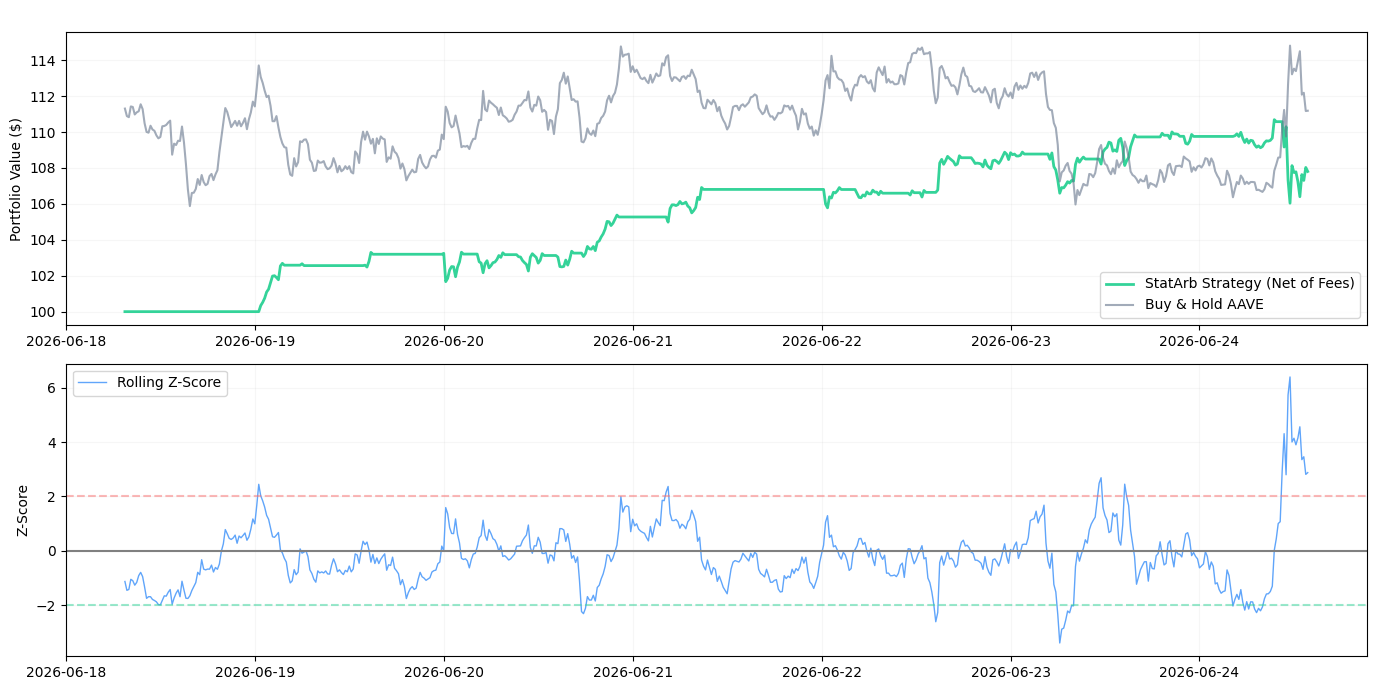

In [7]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def fetch_data(symbol, timeframe='15m', limit=4000):
    exchange = ccxt.binance()
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df['close']

print("📥 Téléchargement de l'historique (4000 bougies 15m) pour le Backtest...")
sym1, sym2 = 'AAVE/USDT', 'ETH/USDT'
df1 = fetch_data(sym1, limit=4000)
df2 = fetch_data(sym2, limit=4000)

df = pd.concat([df1, df2], axis=1).dropna()
df.columns = [sym1, sym2]

print("⚙️ Calcul du Spread et du Z-Score Glissant (Rolling)...")
# 1. Calcul des rendements logarithmiques (plus précis pour le StatArb)
log_p1 = np.log(df[sym1])
log_p2 = np.log(df[sym2])

# On utilise une fenêtre glissante (ex: 200 bougies = ~2 jours)
window = 200

# Calcul du ratio dynamique (Hedge Ratio) sur la fenêtre glissante
# Pour simplifier, on prend le ratio des prix, mais en vrai StatArb on fait une régression OLS glissante
ratio = df[sym1].rolling(window).mean() / df[sym2].rolling(window).mean()

# Le Spread (l'écart)
spread = df[sym1] - (ratio * df[sym2])

# Le Z-Score glissant (moyenne et écart-type des 200 dernières bougies uniquement)
spread_mean = spread.rolling(window).mean()
spread_std = spread.rolling(window).std()
df['zscore'] = (spread - spread_mean) / spread_std

# 2. Génération des Signaux de Trading
df['signal'] = 0 # 0 = Hors du marché

# Règle d'entrée : Z-Score > 2 ou < -2
df.loc[df['zscore'] > 2.0, 'signal'] = -1  # Short Spread (Short AAVE, Long ETH)
df.loc[df['zscore'] < -2.0, 'signal'] = 1  # Long Spread (Long AAVE, Short ETH)

# Règle de sortie : Z-Score croise 0 (retour à la moyenne)
# On garde la position ouverte jusqu'à ce que la condition s'inverse ou touche 0
df['position'] = df['signal'].replace(to_replace=0, method='ffill')

# Si on a un Long (+1) et que le Z-Score repasse au-dessus de 0 -> On coupe (0)
df.loc[(df['position'] == 1) & (df['zscore'] >= 0), 'position'] = 0
# Si on a un Short (-1) et que le Z-Score repasse en-dessous de 0 -> On coupe (0)
df.loc[(df['position'] == -1) & (df['zscore'] <= 0), 'position'] = 0

df['position'] = df['position'].shift(1) # Décalage de 1 pour éviter le look-ahead bias

# 3. Calcul des rendements (PnL)
# Rendement du spread = Rendement AAVE - Rendement ETH
df['ret_sym1'] = df[sym1].pct_change()
df['ret_sym2'] = df[sym2].pct_change()

# PnL de la stratégie (Rendement du spread * direction de la position)
# Si position = 1 (Long Spread) : on gagne si AAVE surperforme ETH
# Si position = -1 (Short Spread) : on gagne si ETH surperforme AAVE
df['strategy_ret'] = df['position'] * (df['ret_sym1'] - df['ret_sym2'])

# 4. Application des Frais de Transaction (0.05% Taker par patte = 0.10% par trade, 0.20% aller-retour)
# On paie les frais à chaque fois que la position change (de 0 à 1, de 1 à 0, etc.)
df['trade_happened'] = df['position'].diff().abs()
frais_par_patte = 0.0005 # 0.05%
frais_total_trade = frais_par_patte * 2 # Car on trade AAVE ET ETH
df.loc[df['trade_happened'] > 0, 'strategy_ret'] -= frais_total_trade

# 5. Calcul de l'Equity Curve (Portefeuille qui commence à 100$)
df['equity'] = 100 * (1 + df['strategy_ret']).cumprod()
df['buy_and_hold_aave'] = 100 * (1 + df['ret_sym1']).cumprod() # Pour comparer

# Nettoyage des NaN dus au Rolling
df = df.dropna()

# --- Résultats ---
pnl_net = df['equity'].iloc[-1] - 100
total_trades = df['trade_happened'].sum() / 2 # /2 car Entrée + Sortie = 1 Trade
win_rate = "À calculer" # Nécessite une boucle complexe en vectorisé, on va au PnL brut d'abord

print("\n" + "="*60)
print("📊 RÉSULTATS DU BACKTEST (Période ~40 jours)")
print("="*60)
print(f"PnL Net (Frais déduits) : {pnl_net:+.2f} $ (sur 100$ de départ)")
print(f"Nombre de Trades allers-retours : {int(total_trades)}")
print("="*60)

# --- Graphique ---
plt.style.use('default')
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.title('Simulated Equity Curve (StatArb Z-Score) vs Buy & Hold AAVE', color='white')
plt.plot(df.index, df['equity'], label='StatArb Strategy (Net of Fees)', color='#34d399', linewidth=2)
plt.plot(df.index, df['buy_and_hold_aave'], label='Buy & Hold AAVE', color='#64748b', alpha=0.6)
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(alpha=0.1)

plt.subplot(2, 1, 2)
plt.plot(df.index, df['zscore'], label='Rolling Z-Score', color='#60a5fa', linewidth=1)
plt.axhline(2, color='#f87171', linestyle='--', alpha=0.5)
plt.axhline(-2, color='#34d399', linestyle='--', alpha=0.5)
plt.axhline(0, color='gray', linestyle='-')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(alpha=0.1)

plt.tight_layout()
plt.show()